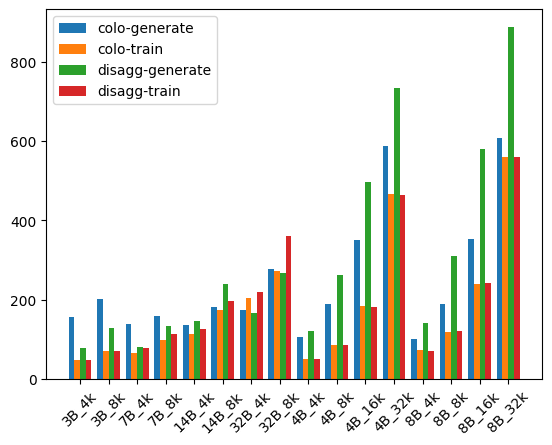

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime


def parse_phase_time(file: str, job_name: str, log_type='sched'):
    with open(file, 'r') as f:
        content = f.read().split("\n")
    ts = {phase: [] for phase in ['generate', 'train']}
    te = {phase: [] for phase in ['generate', 'train']}
    for line in content:
        for phase in ['generate', 'train']:
            pattern_start = f"Event(job={job_name}, phase={phase}, type=status, value=running"
            pattern_end = f"Event(job={job_name}, phase={phase}, type=done"
            if pattern_start in line:
                t = datetime.strptime(line.split(" |")[0], '%Y/%m/%d %H:%M:%S') if log_type == "sched" else datetime.strptime(line[:len("[2025-10-10 15:57:12]")], '[%Y-%m-%d %H:%M:%S]')
                ts[phase].append(t)
            if pattern_end in line:
                t = datetime.strptime(line.split(" |")[0], '%Y/%m/%d %H:%M:%S') if log_type == "sched" else datetime.strptime(line[:len("[2025-10-10 15:57:12]")], '[%Y-%m-%d %H:%M:%S]')
                te[phase].append(t)
    return ts, te

t = {method: {} for method in ['colo', 'disagg']}
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".out"):
            model_size = root.split('-')[-1]
            assert model_size in [f'{i}B' for i in [3, 4, 7, 8, 14, 32]]
            method, length = file[:-4].split('_')
            assert method in ['disagg', 'colo']
            if model_size in ['4B', '8B']:
                assert length in [f'{i}k' for i in [4, 8, 16, 32]]
            else:
                assert length in ['4k', '8k']
            sched = 'sched' if method == 'disagg' else ('sched' if model_size in ['4B', '8B'] else None)
            ts, te = parse_phase_time(os.path.join(root, file), 'job1', sched)
            t[method][f'{model_size}_{length}'] = {}
            for phase in ['generate', 'train']:
                t[method][f'{model_size}_{length}'][phase] = float(np.mean([(end - start).total_seconds() for start, end in zip(ts[phase], te[phase])]))

w = 0.2
i = 0
for method in ['colo', 'disagg']:
    for phase in ['generate', 'train']:
        data = {setting: t[method][setting][phase] for setting in t[method]}
        def order(setting: str):
            model_size, length = setting.split('_')
            model_size = int(model_size[:-1])
            length = int(length[:-1])
            return (model_size in [4, 8], model_size, length)

        data = {setting: data[setting] for setting in sorted(data.keys(), key=order)}
        plt.bar([x + i * w for x in range(len(data))], data.values(), width=w, label=f'{method}-{phase}')
        if i == 0:
            plt.xticks([x + 1.5 * w for x in range(len(data))], data.keys(), rotation=45)
        i += 1
plt.legend()

In [2]:
import json

with open("../profile.json", 'w') as f:
    json.dump(t, f)